<img style="float: center;" src='https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_header.png' alt="stsci_logo" width="900px"/> 

# JWebbinar50: Introduction to Jdaviz 5.0, Part I

_July 7, 2026_

**Authors**: Sarah Betti (STScI), Clare Shanahan (STScI)<br>
**Jdaviz Version**: 5.0.2

- [Documentation](https://jdaviz.readthedocs.io/en/latest/index.html)
- [Source code](https://github.com/spacetelescope/jdaviz)

## Tutorial Outline

This tutorial will demonstrate features recently introduced (since ~spring 2026) to Jdaviz, with a focus on using the UI for workflows.

This notebook will walk you though how to:
- load an image from astroquery using a URL/URI
- change the image plot options for clearer visualization
- using astroquery to visualize observations and load in new observations


Some of the new features demonstrated in this notebook include:
- opening both images and spectra into jdaviz
- using astroquery to find and open datasets

This tutorial will be done purely through the UI. However, this notebook provides the equivalent API calls 

Note: If you are unable to use the UI, we do provide all of the API calls at the bottom of this notebook. 

## Set up jdaviz

We first want to open the `jdaviz` application in our notebook. 

By default, the app will open in-line with the notebook cells. By choosing the 'sidecar' display location option, it will open to the right of the notebook so we can see both the notebook and the app.  _Note: This only works in jupyter lab environments._ 


Other options are:
- inline: Will appear below the `jd.show(loc='inline')` cell
- popout: Open an external browser windows  

In [ ]:
import jdaviz as jd
jd.show(loc='sidecar', height=800)

## Load data

Now, we will load an example JWST image of part of the Chamaeleon I star forming region, observed as part of the NIRCam Early Release Science Observation program ID 1309 (The Ice Age program; PI: M. McClure).  
This star forming region is ~192 pc away from us and home to many young protostars. More information on the Ice Age program can be found here: [https://jwst-iceage.org](https://jwst-iceage.org)  

We are going to load in a small subset of the larger SFR imaged with NIRCam in the F200W filter.  

On the left side in the data loading panel, select the `Source` drop down.  You will see that there are several options to chose from.  For now, we are going to select `url` which will allow us to directly download the data from the web.  

Under the `Download from URL` header, next to the link icon, copy and paste the following MAST URL:

> `mast:JWST/product/jw01309-o025_t005_nircam_clear-f200w_i2d.fits`

This will pull this Level 3 .fits file directly from the MAST archive and load it into Jdaviz.  It might take a minute two to load as it is a ~3GB file! 

Once the Importer section is filled out, we will scroll down and select `WCS` for how we want to align our pixels!  Then press the orange `Import` button to load it into `jdaviz`.
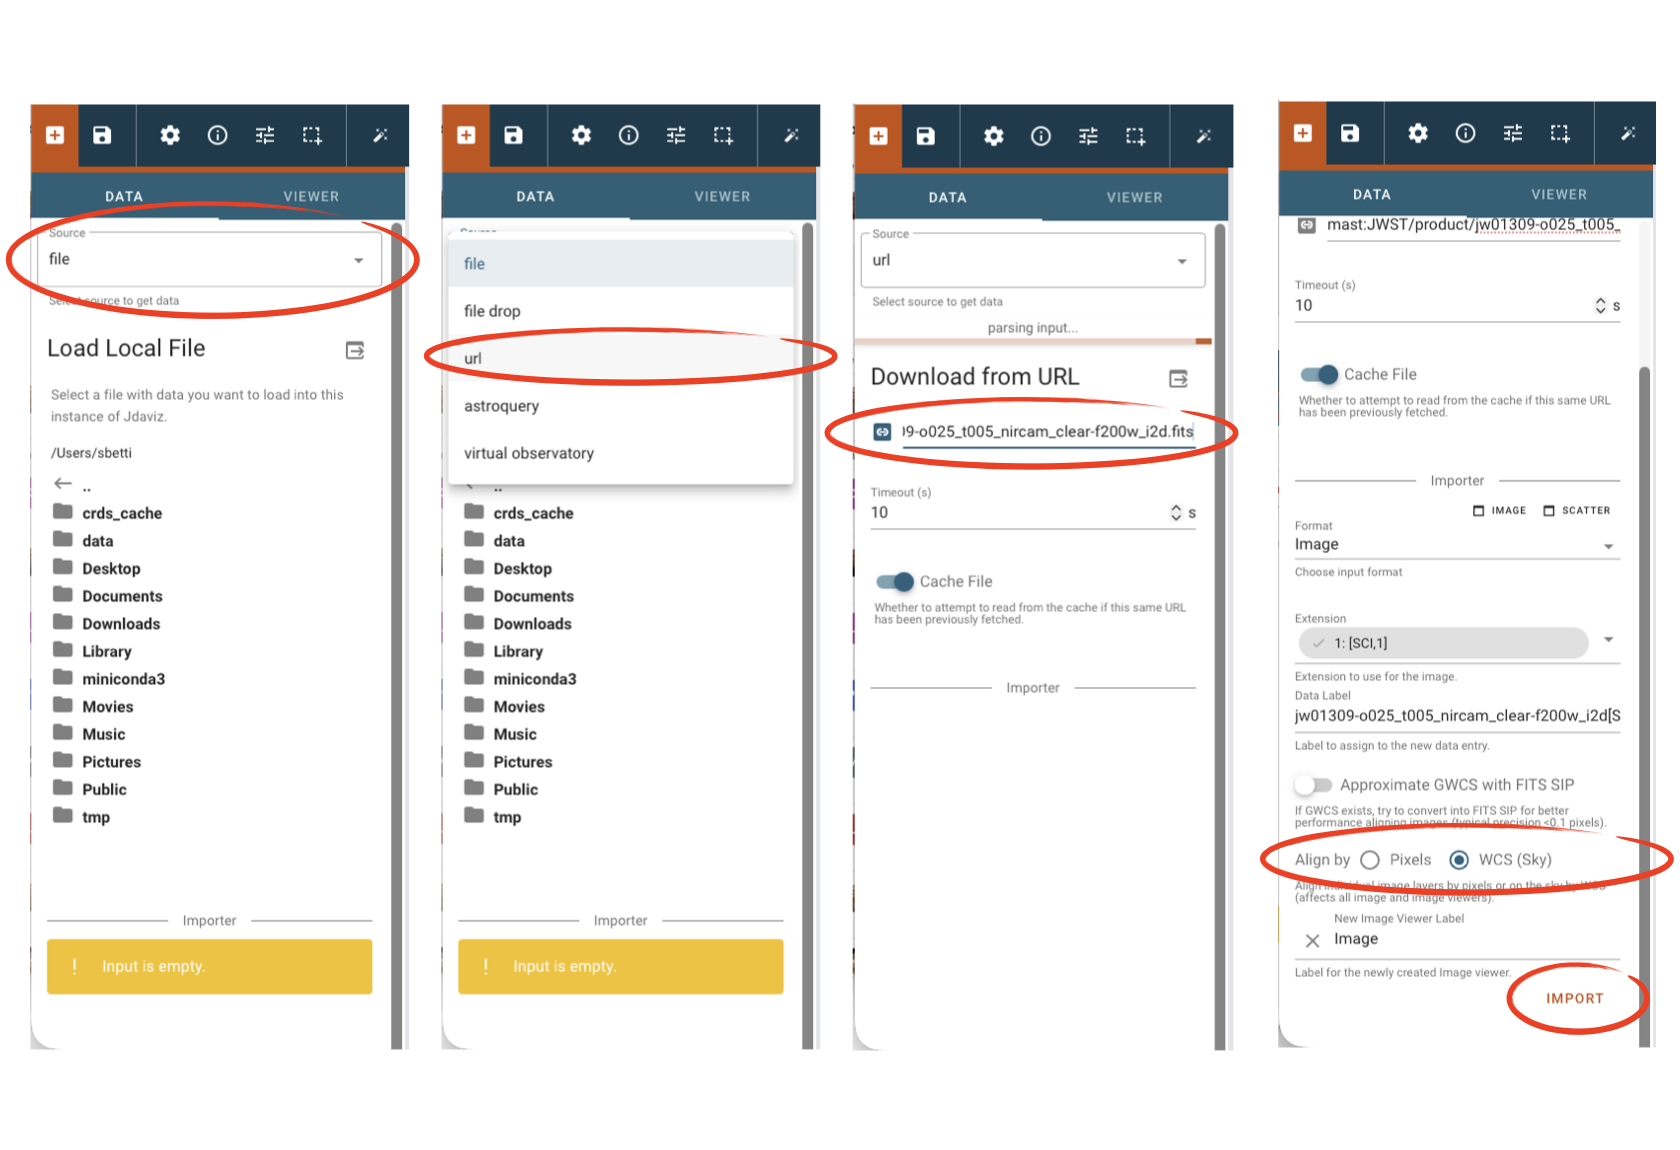

## Renaming datasets

One of the new features in `jdaviz` is the ability to change the dataset name in the data menu.  Select the `A` in the data menu and you can see our image is named `jw01309-o025_t005_nircam_clear-f200w_i2d[SCI,1]` which gives us the MAST information, but not any information about the image itself.  

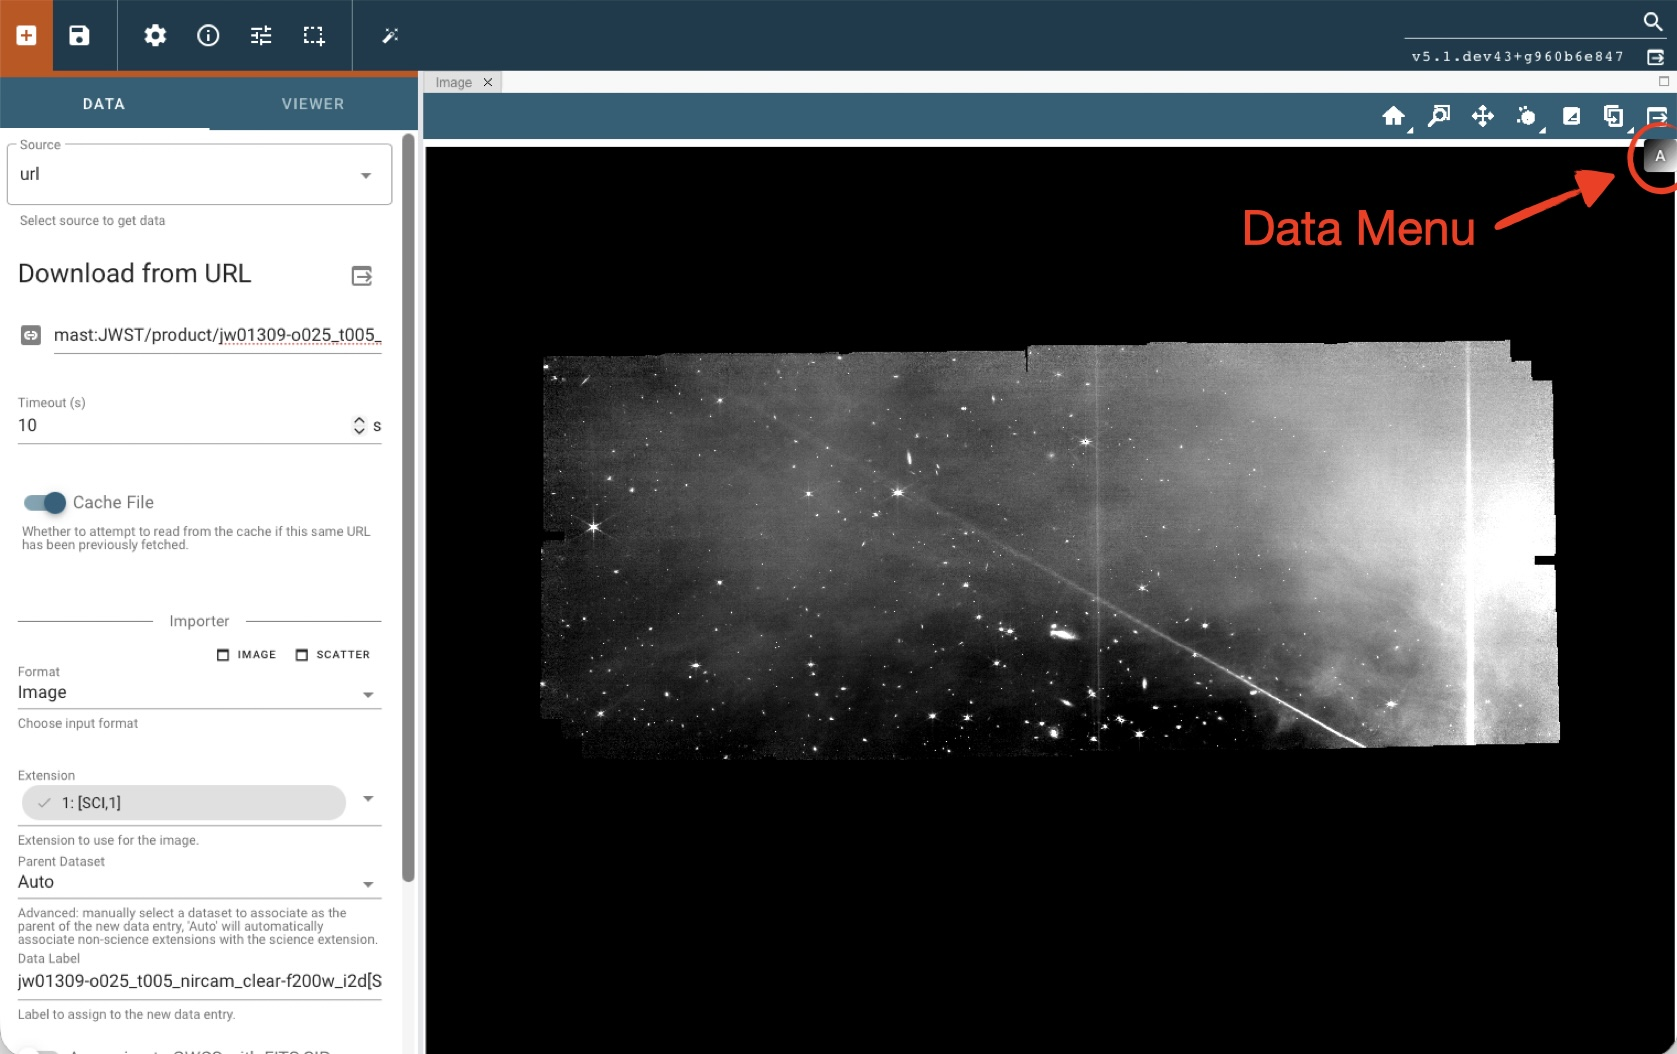

We can therefore rename it to something easier to understand.  Let's try "Chamaeleon I SE side". To do this, first click on the `A`, then hover over the current name until a pencil appears.  Click on the pencil and rename the image. Click on the check to apply it. 
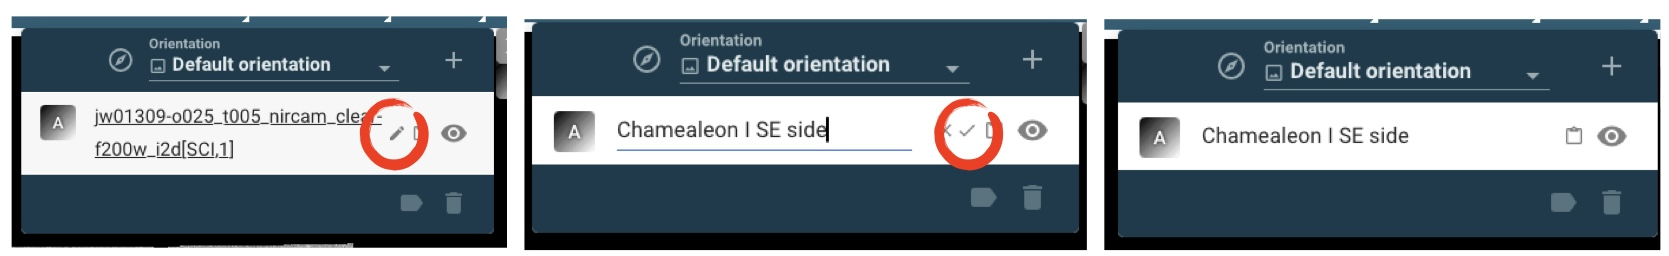

# Changing the plot options

Let's adjust some of the `Plot Options` parameters to make this image a bit clearer in `jdaviz`. Click on the gear icon on the top left to open the `Plot Options` plugin.  We can see the `A` legend label is highlighted and there are several imaging options in the gray panel below. You can play around with the features.  

Let's change:
- colormap: Viridis
- stretch functions. These are found under the `More Stretch Options`. 
    - `Stretch VMin`: `0.4`
    - `Stretch VMax`: `0.85`
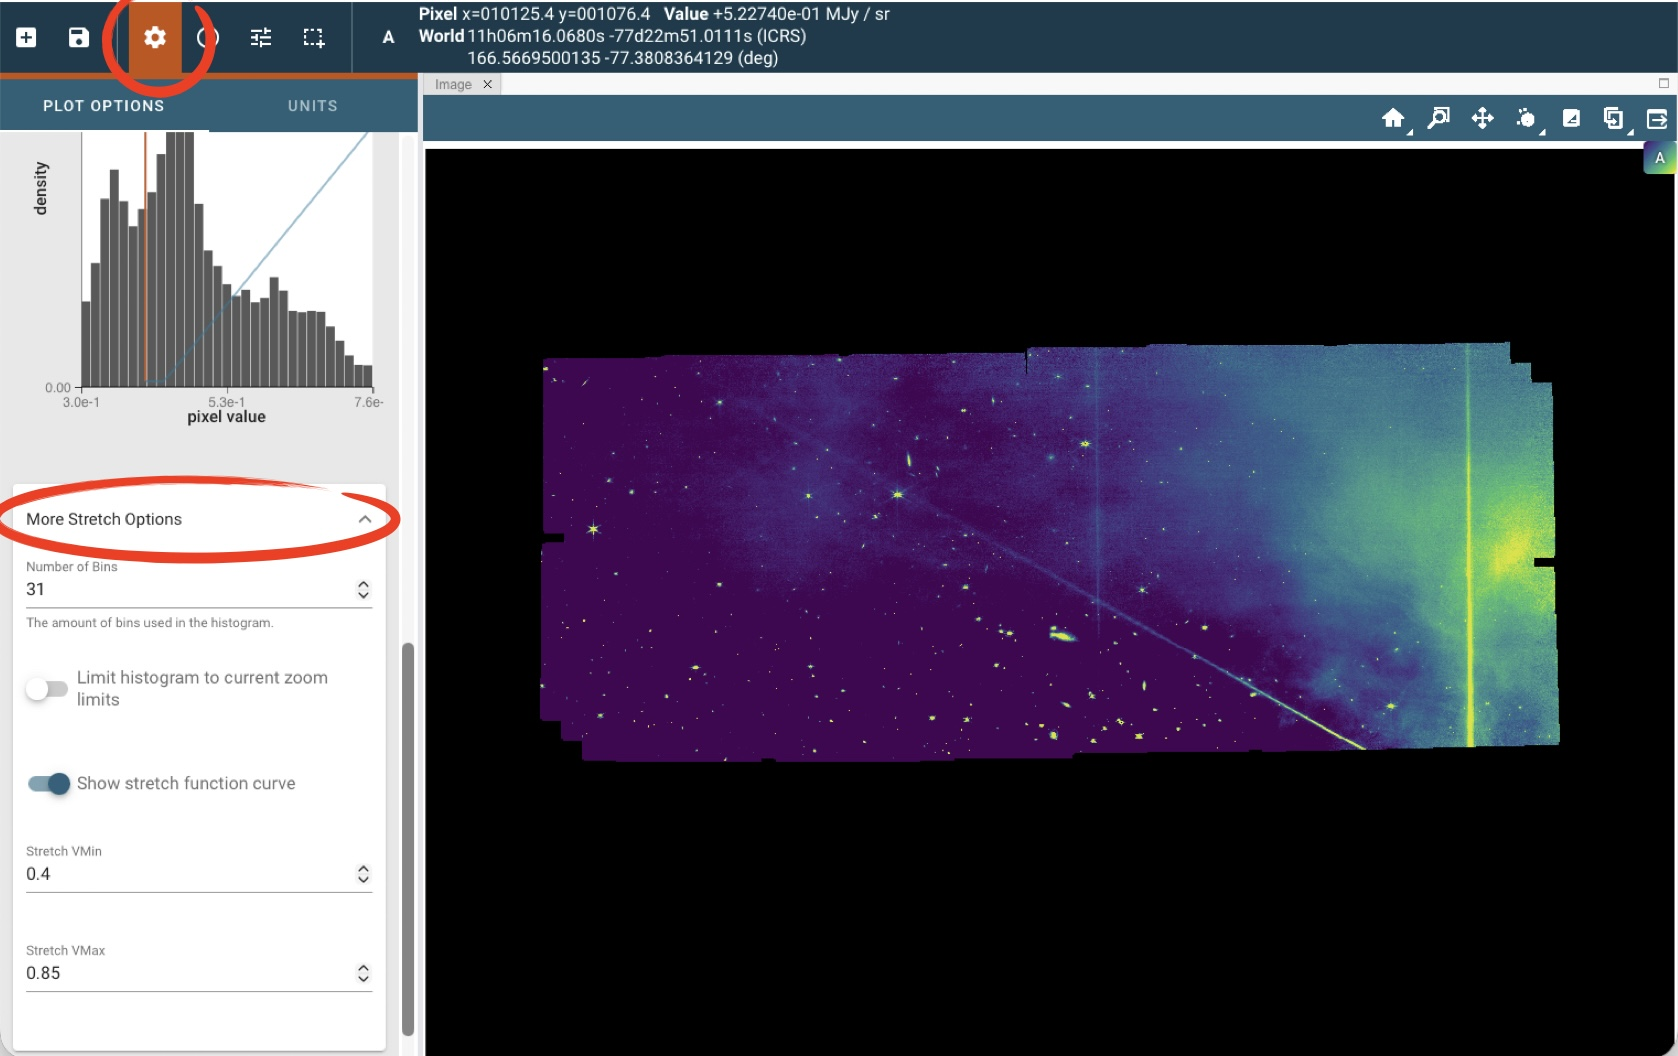

# Using Astroquery



Now that we've loaded in our image, we now want to see what else has been observed in the field of view of our image.  Have any stars been observed with NIRSpec and if so, can we load their spectra into `jdaviz`?  Let's use astroquery.  [Astroquery](https://astroquery.readthedocs.io/en/latest/) is a tool set used for querying astronomical web forms and databases which has been implemented into `jdaviz`.  

### Aside: Subsets
For this tutorial, we have the foreknowledge that several of these stars have been observed with NIRSpec as part of the Ice Age program.  The spectrum that we will use here has been published in [McClure et al., 2023](https://www.nature.com/articles/s41550-022-01875-w). Our star of choice, SSTSL2J110621.63-772354.1, is found within our NIRCam FOV.  As a quick aside, lets highlight it using a subset.  In the `Image` viewer, click the circle icon on the right hand toolbar. Then click and drag anywhere on the image to create a subset.  

Now, on the left hand plugin menu, click on the dashed square icon to get into the `Subset Tools` plugin menu. The subset (`Subset 1`) we just created should be shown.  Below, in the Subregion 0 menu, you should see `RA Center` and `Dec Center`.  
Change: 
- `RA Center`: `166.59019` 
- `Dec Center`: `-77.39823`.
- `Radius`:`0.001`
  
Click the `Update` button to apply.

Now, select the zoom button on the `Image` viewer and drag a box around your circle to zoom in.  You should be able to see a faint star in the center, with our red subset around it. Our subset is also in the `data menu` on the right.  If you hover over the `B`, it should give you `Subset 1`.
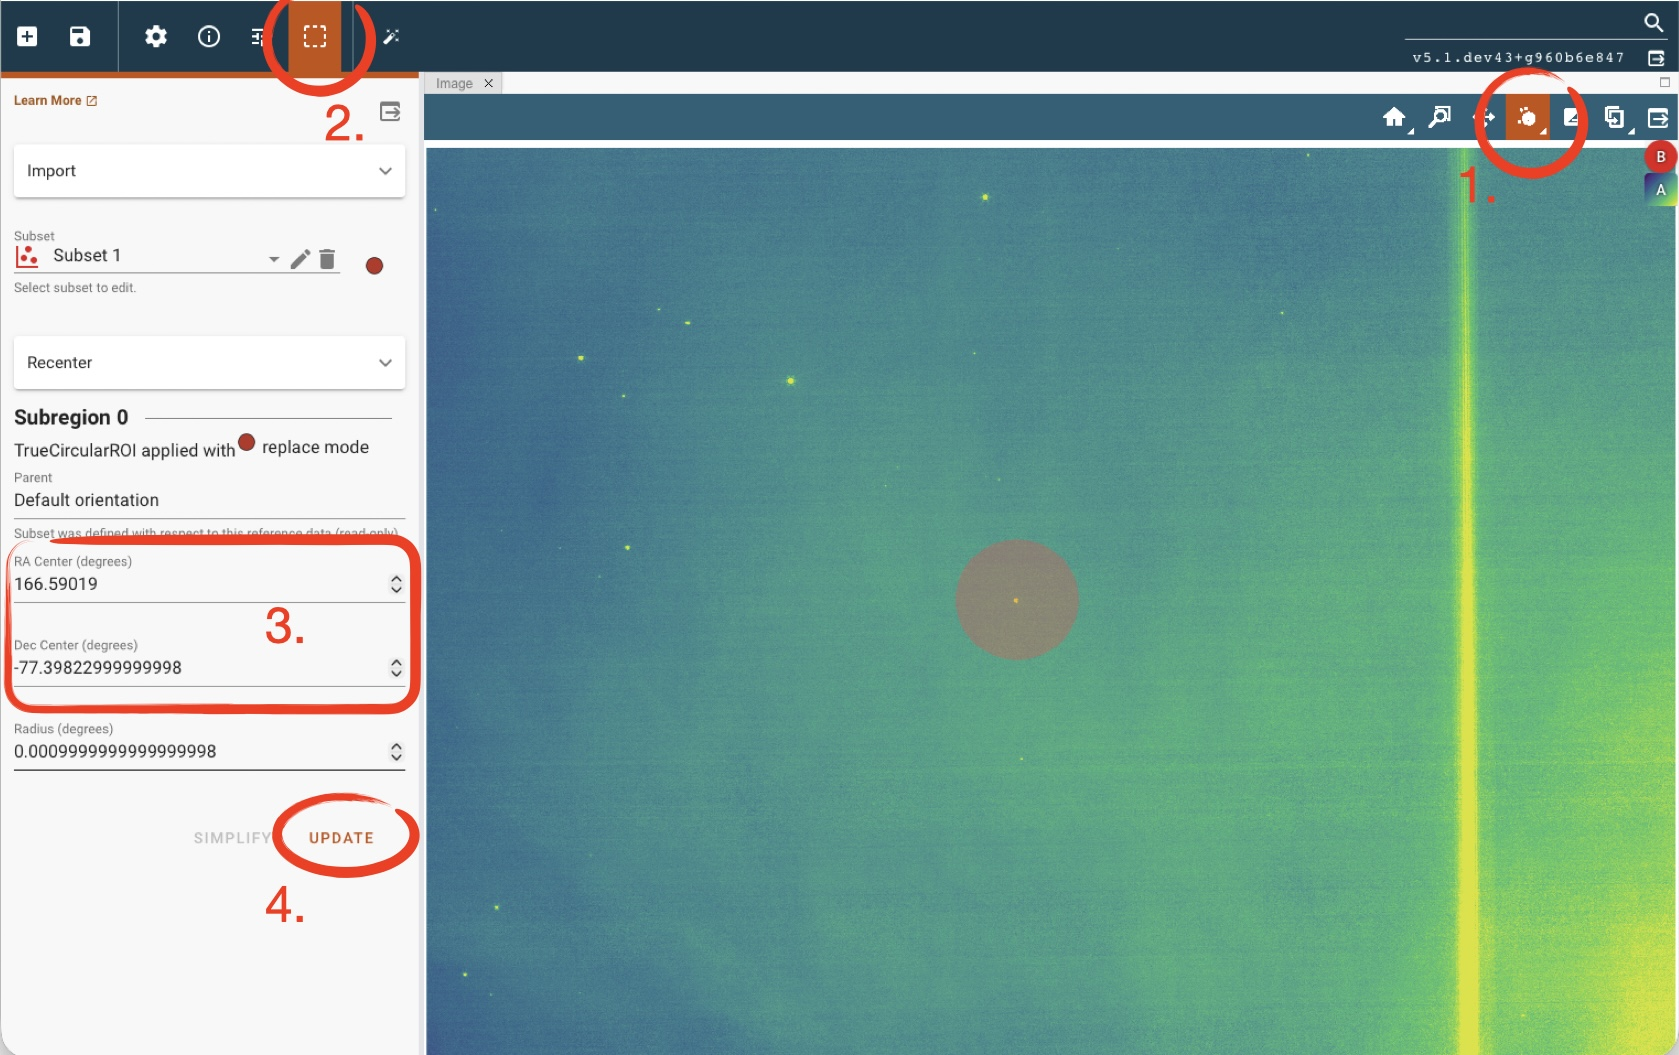

### Back to astroquery
Lets go back to finding our star with astroquery.  Select the 'plus' icon to add new data.  Change the `Source` from `url` to `astroquery`.  Under the source selection
- Viewer: Image
- Select Follow Viewer Center 
Make sure the coordinates are the coordinates of the star! 
- Query Archive

This might take a while! 
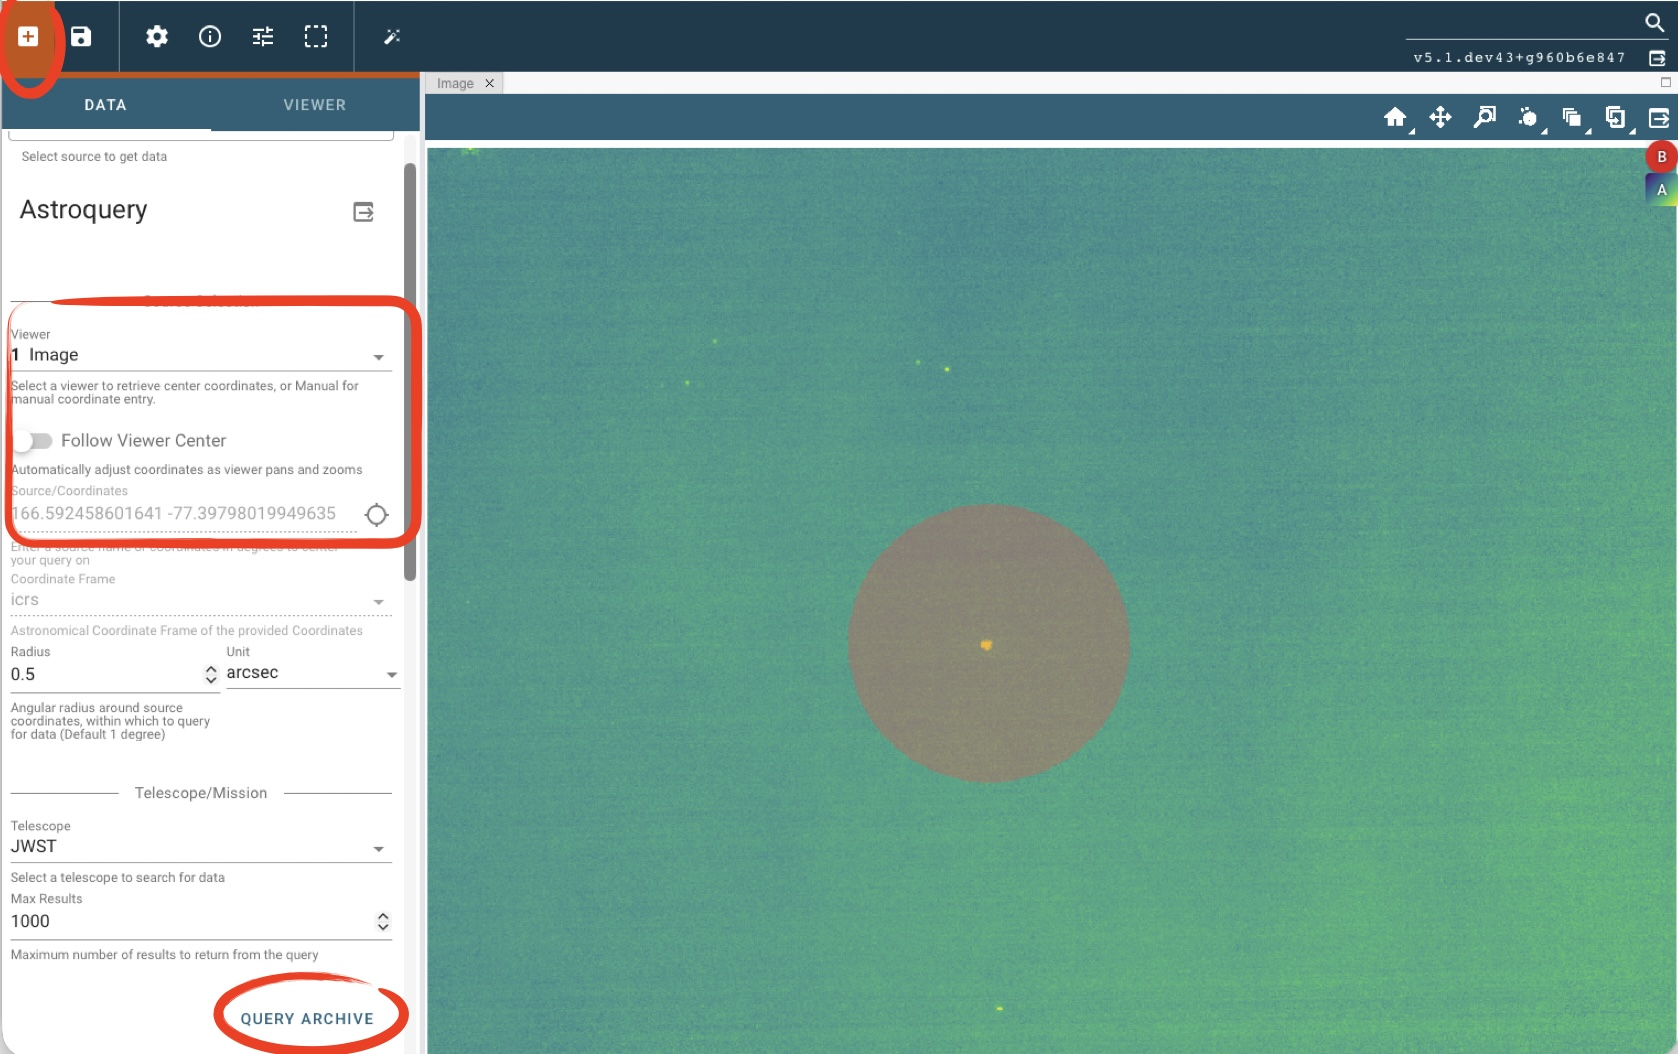

After it finishes, select the `Enable footprint selection Tools`.  You will see a lot of orange squares pop up.  Every box is an observation taken with JWST -- This is a very popular field!
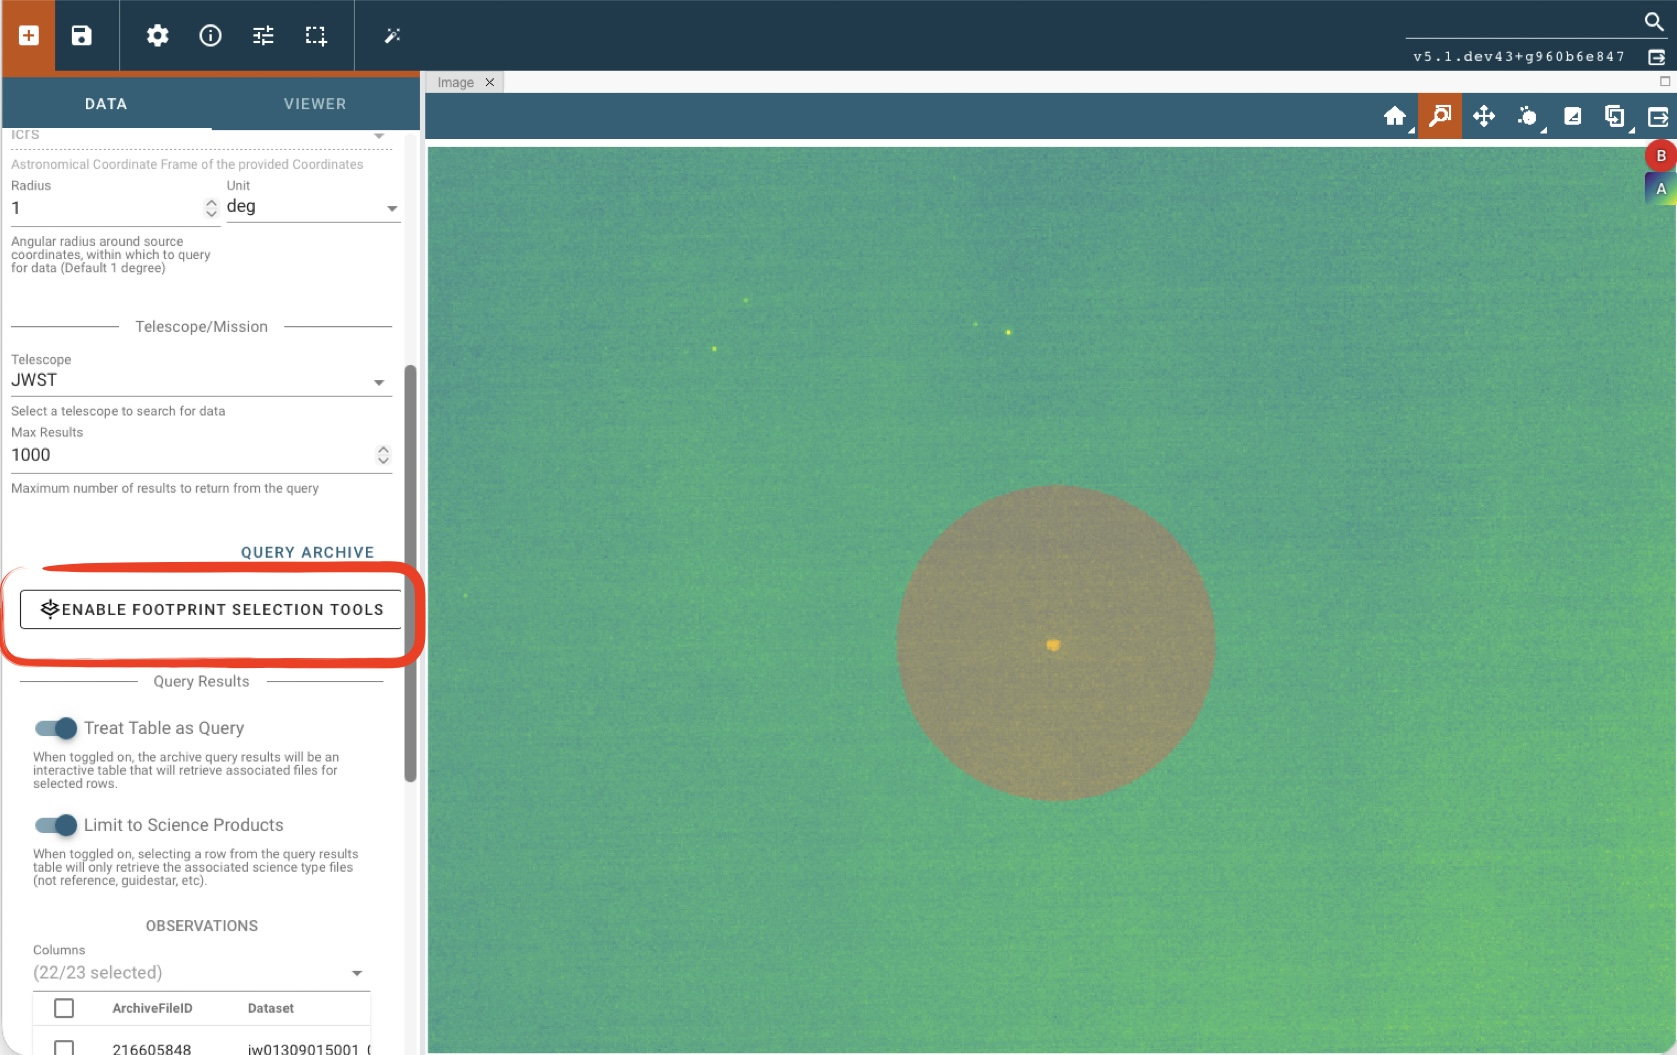

There should now be a table under the `Enable footprint selection Tools` button that gives all of the returned data products on MAST.  This is a lot to parse through, so instead, we will use the `Footprint Selection` tools to help us out! Select the diamond on the far right side of the `Image` toolbar. This button will allow us to select an observation and pull up the data.

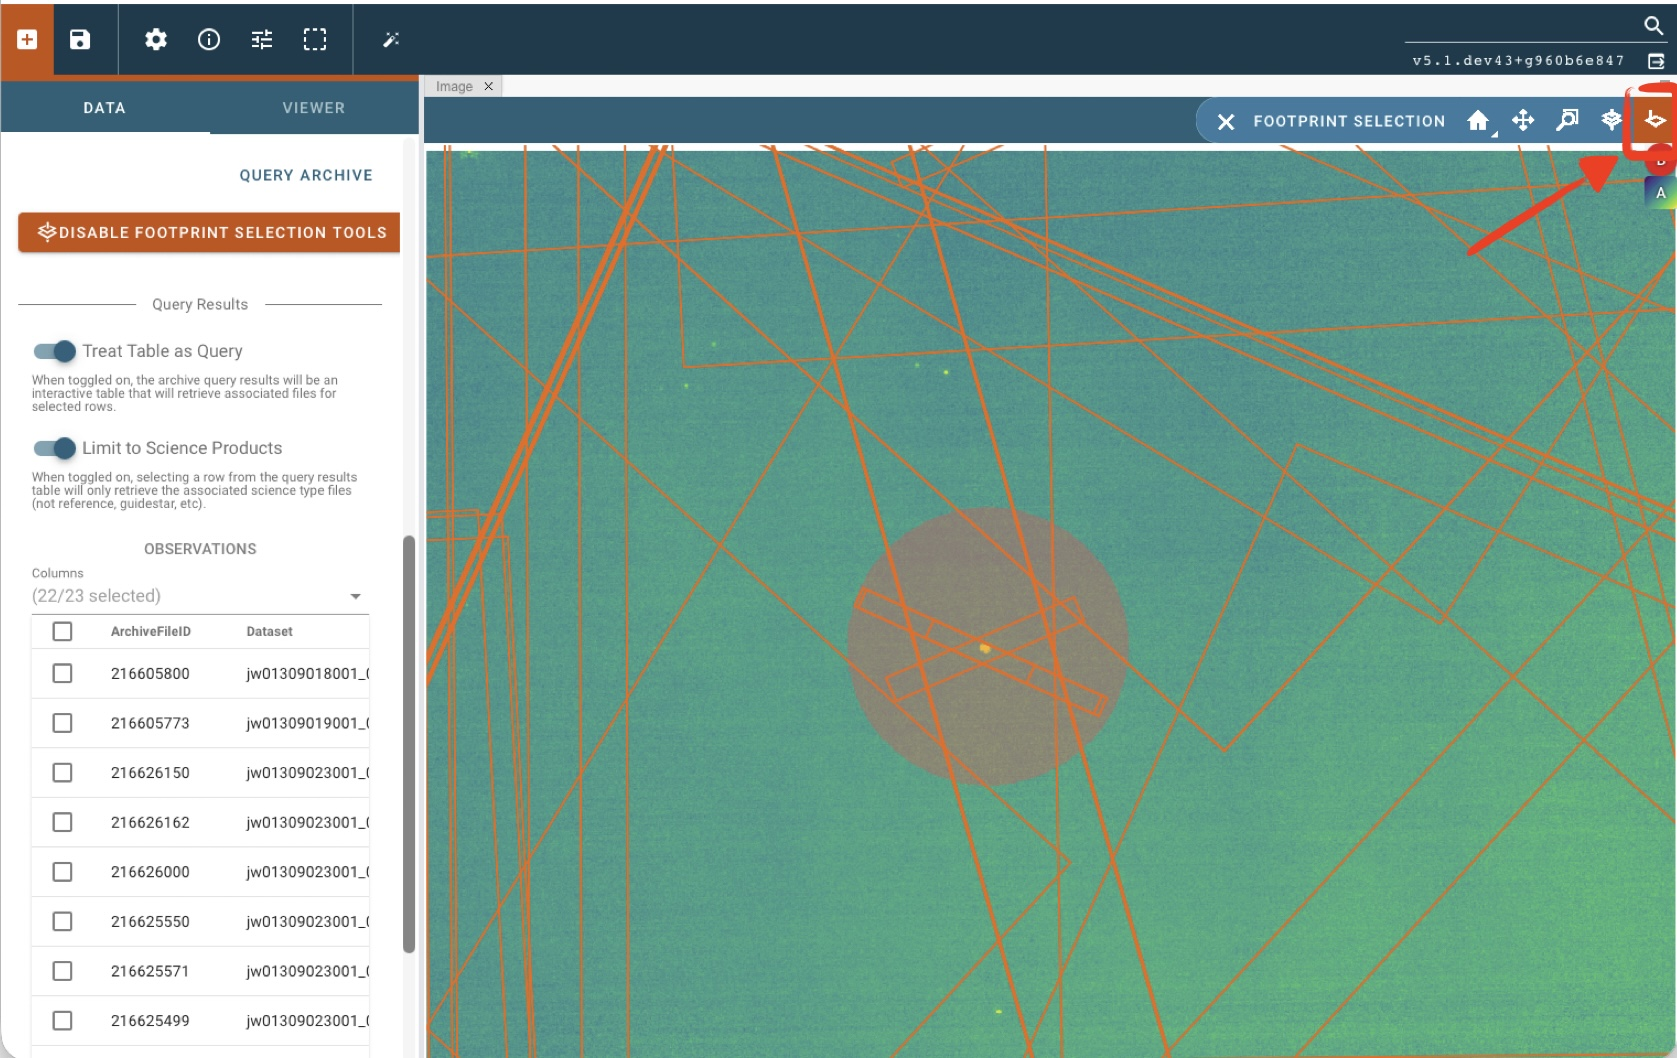

We will select the narrow rectangle (aka NIRSpec slit) that has the lower side on the left.  

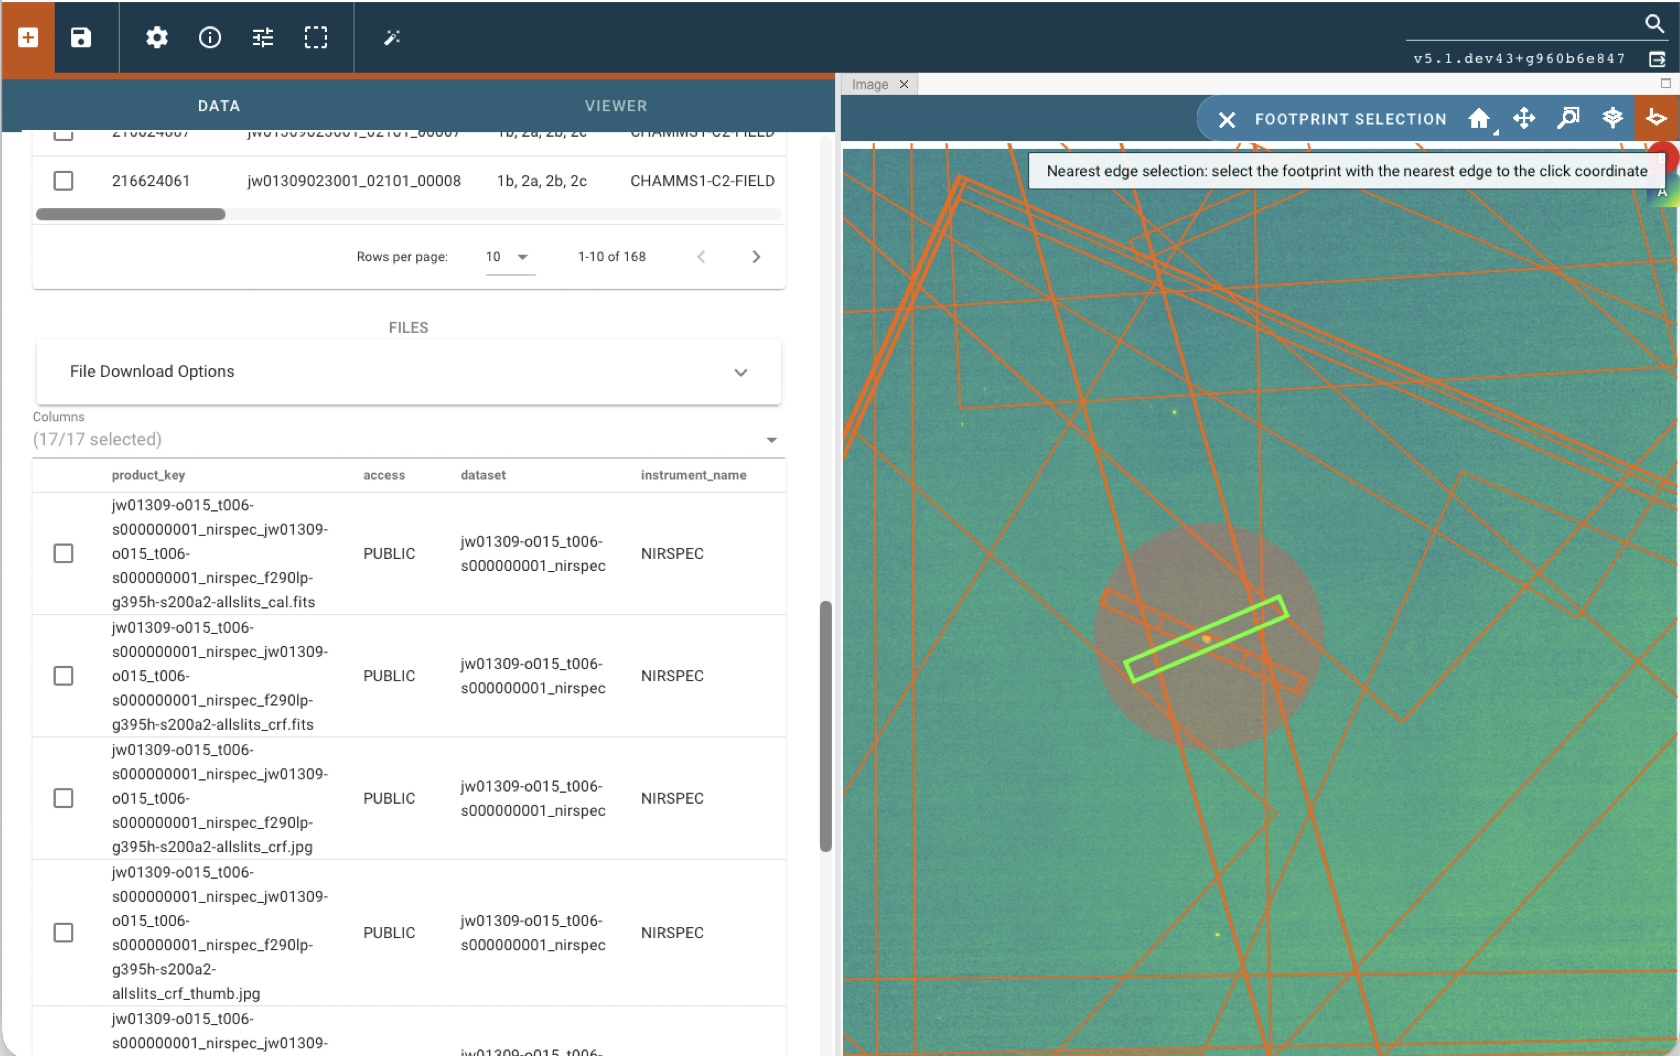
Scrolling down on the menu there are now a set of files that appear for that observation.  We want to select the one with the `x1d.fits` in the filename.  This is the Level 3 calibrated spectrum.  

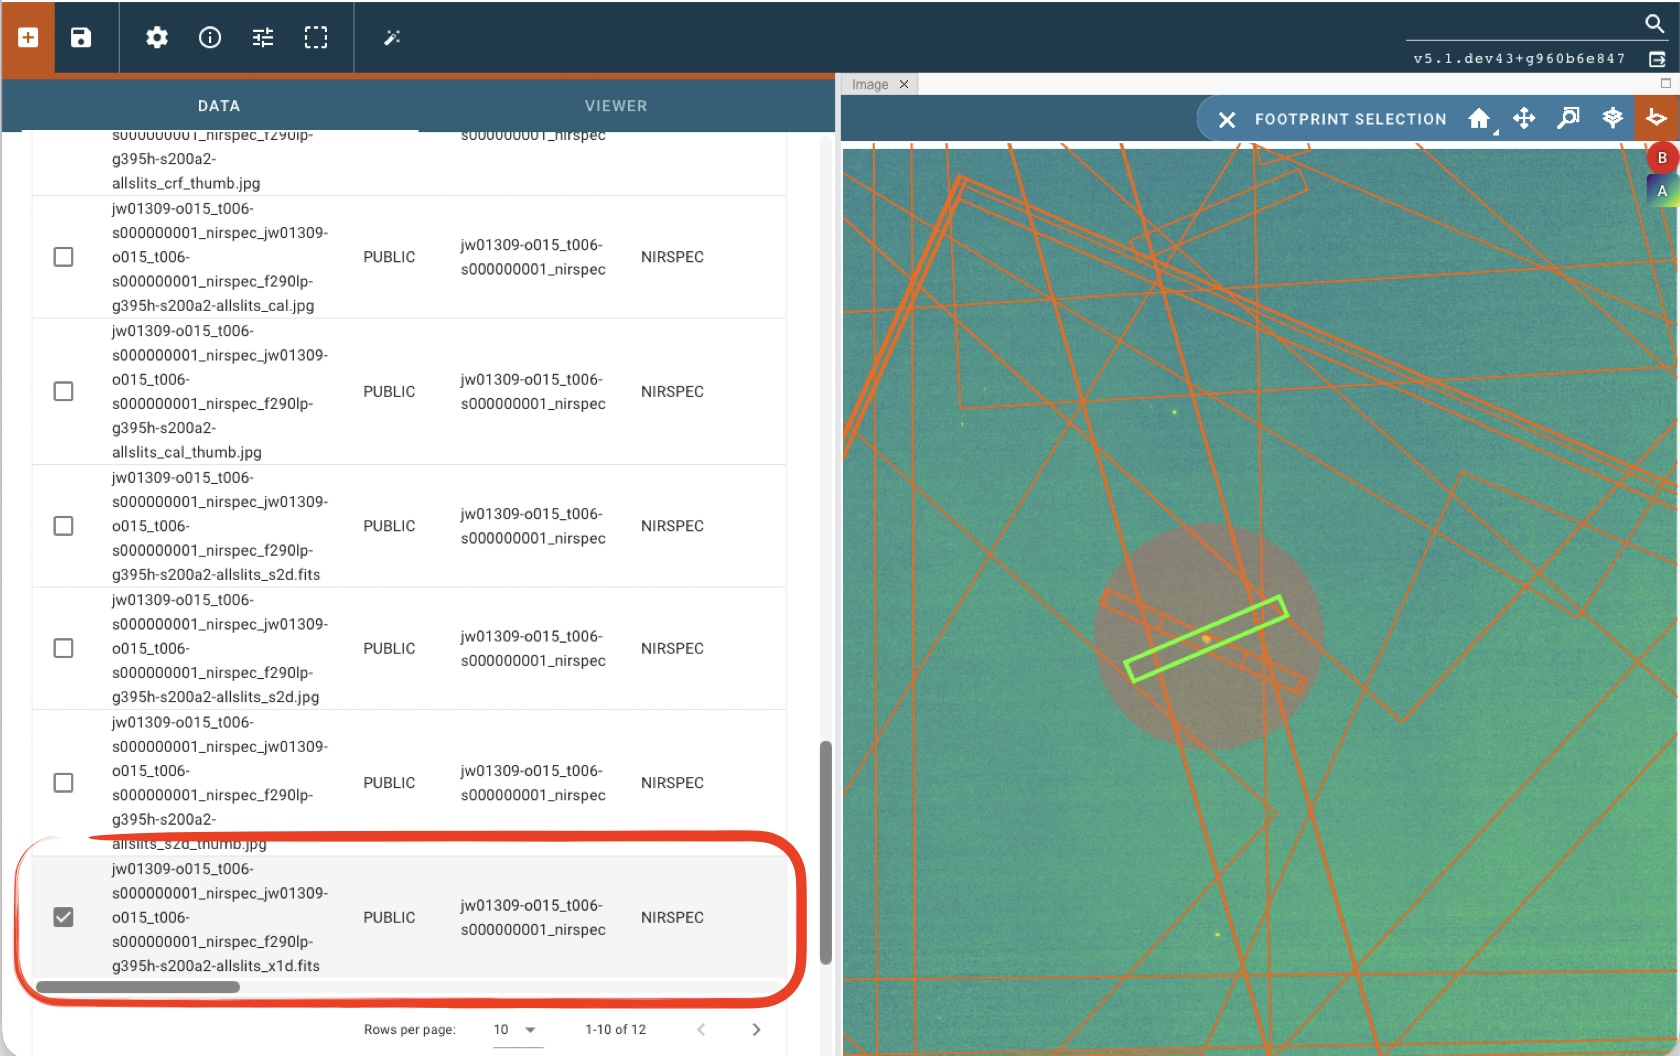

Scroll further down and press Import.   This will create a `1D Spectrum` viewer and plot the spectrum! You might notice the spectrum looks like a flat line! Click on the house icon in the `1D Spectrum` viewer to automatically change the y limits.  
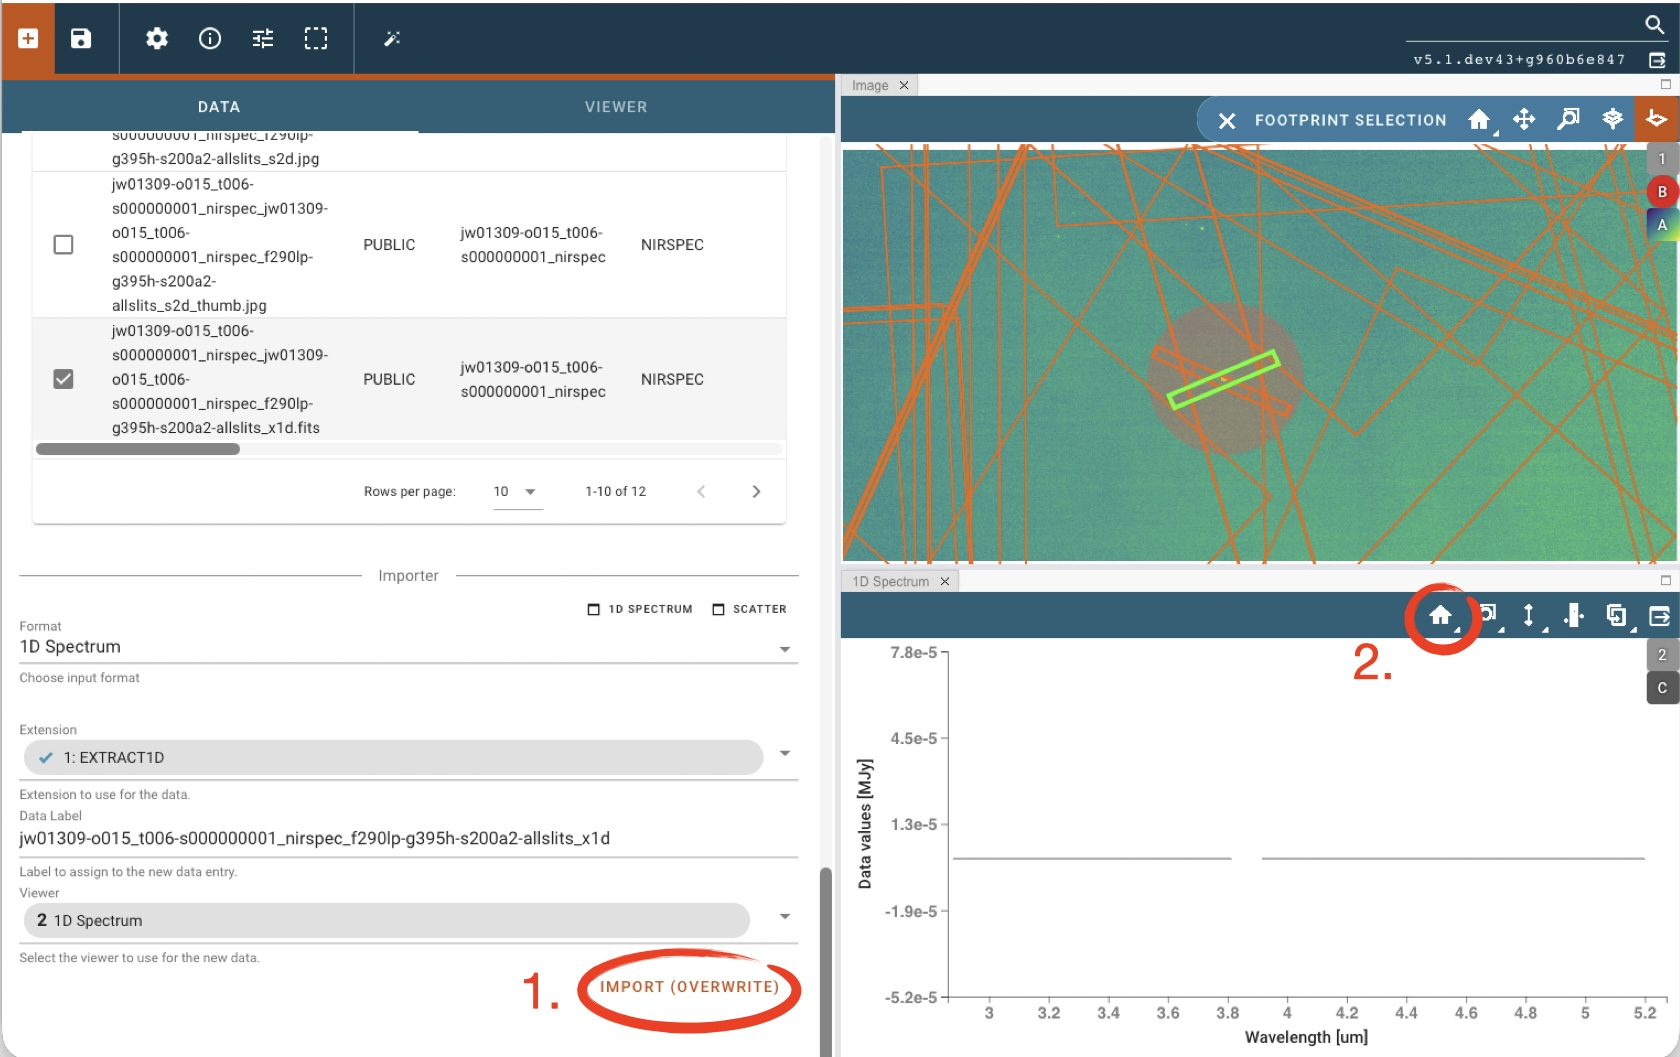



Now we can see our beautiful protostar spectrum!  The dip at 3 um is water ice.  The absorption dips at 4.2-4.4 microns are CO2 ice and 4.67 microns is CO ice.  (_Note: The colors are created using `jdaviz` subsets and the labels are created in powerpoint!_)

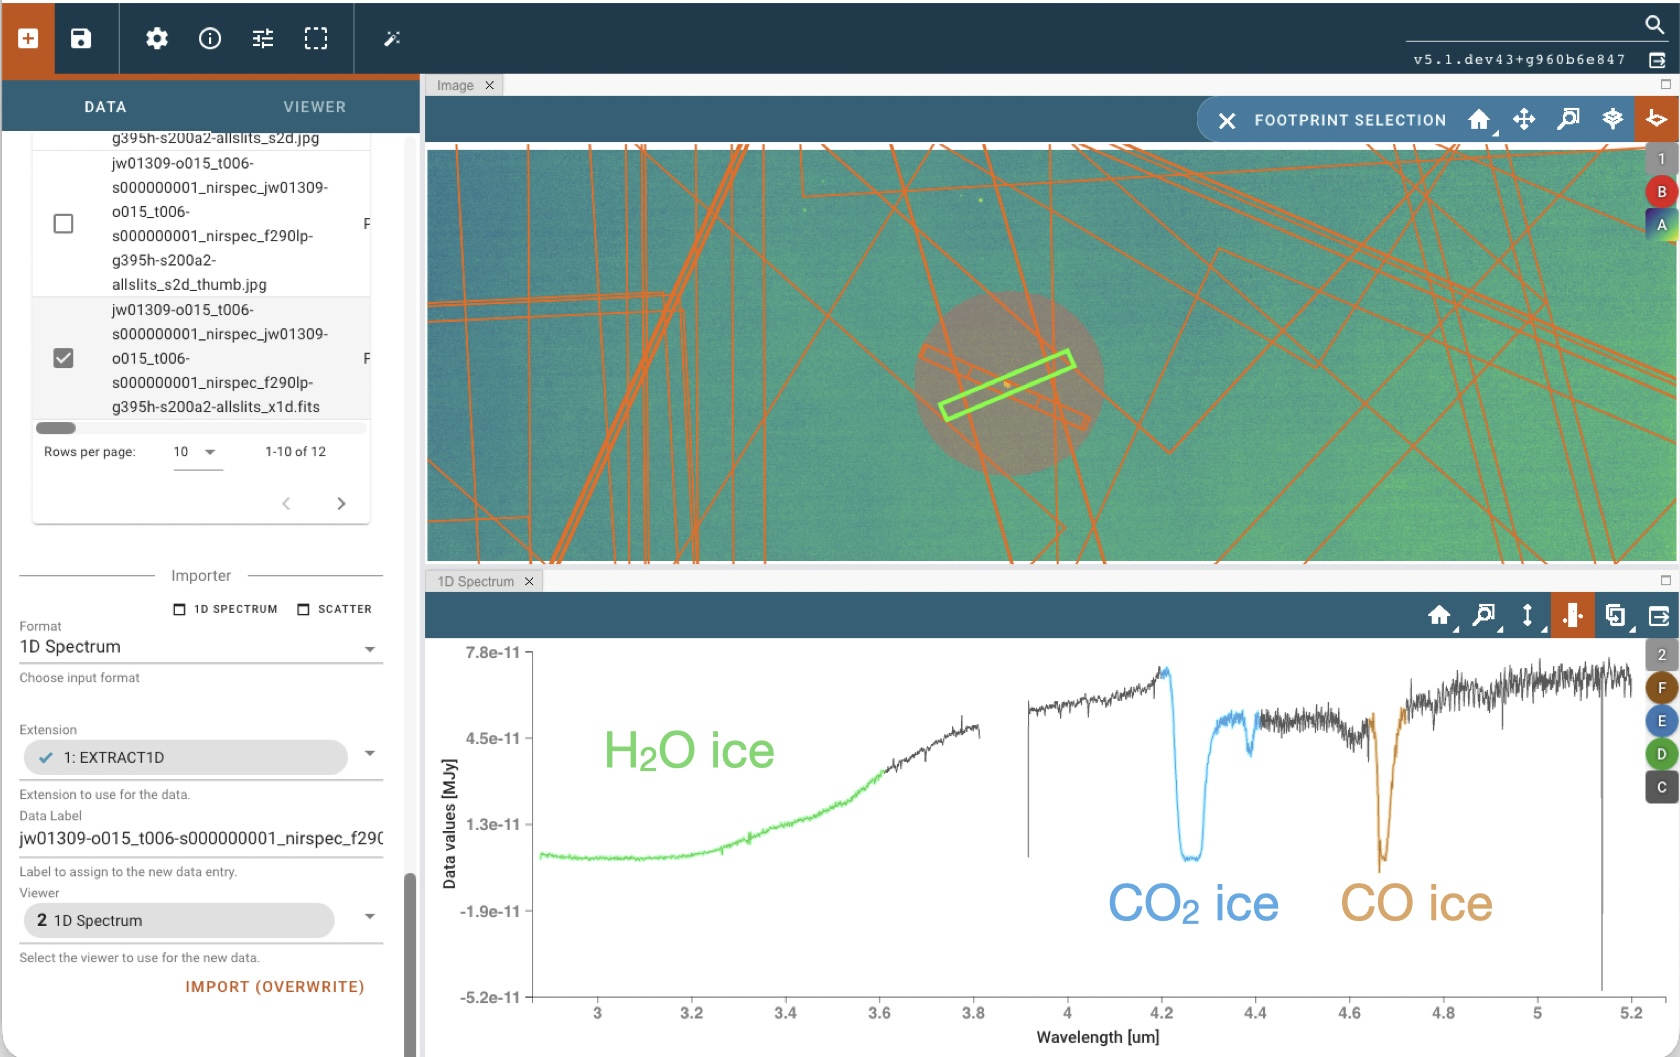

---
# For those that cannot use the UI, we provide all of the API calls for this tutorial below! 

In [ ]:
# Import modules
import jdaviz as jd

import time
import numpy as np

from astropy import units as u
from astropy.coordinates import SkyCoord

from photutils.aperture import SkyCircularAperture

In [ ]:
# load file into jdaviz.  Use the Image format and name the file during the loading!
jd.load('mast:JWST/product/jw01309-o025_t005_nircam_clear-f200w_i2d.fits', 
        format='Image', data_label = 'Chamaeleon I SE side')

# open the jdaviz application inline
jd.show()

In [ ]:
# change the orientation to use WCS coordinates
# note that this can be done on load as well by selecting 'align by WCS' in the loader, 
# but we can also do this after the fact through the orientation plugin
orientation = jd.plugins['Orientation']
orientation.align_by = "WCS"

In [ ]:
# Change the plot options to use the Viridis colormap and change the vmin and vmax to 0.4 and 0.85, respectively.
plot_options = jd.plugins['Plot Options']

plot_options.image_colormap = 'Viridis'
plot_options.stretch_function = 'Linear'
plot_options.stretch_vmin = 0.4
plot_options.stretch_vmax = 0.85

In [ ]:
# use the subset tools plugin to create a subset on our object of choice. We create it using photutils SkyCircularAperture (which requires 
# an astropy SkyCoord object for its center) and import it into jdaviz.
subset_tool = jd.plugins['Subset Tools']
subset_tool.subset = 'Create New'

c = SkyCoord(ra = 166.59019 * u.degree, dec = -77.39823 * u.degree)
my_aper_sky = SkyCircularAperture(c, 2 * u.arcsec)

subset_tool.import_region(my_aper_sky)

In [ ]:
# now we zoom into the our stellar region
plot_options.viewer = 'Image'
plot_options.zoom_center_x = 166.59019
plot_options.zoom_center_y = -77.39823
plot_options.zoom_radius = 0.001

In [ ]:
# let's load astroquery! We are going to use the zoomed in location to search MAST for JWST data
load = jd.loaders['astroquery']
load.open_in_tray()
load.viewer = 'Image'
load.query_archive()

In [ ]:
# we enable the footprint selection which shows orange squares and rectangles on the UI where observations have been taken.
load.enable_footprint_selection_tools()

In [ ]:
# we export the table of observations that have been taken with JWST
obs_table = load.observation_table.export_table()

In [ ]:
# Lets get the index of the rown with observation we want
observation = obs_table[obs_table['Dataset'] == 'jw01309-o015_t006-s000000001_nirspec']
observation_index = int(np.where(obs_table['Dataset'] == 'jw01309-o015_t006-s000000001_nirspec')[0][0])
print('index is: ', observation_index)
observation

In [ ]:
# we now tell jdaviz which row we want with this index that corresponds to our desired dataset
load.observation_table.select_rows(observation_index)

# we need a small pause to make sure everything is selected correctly on the backend :) 
time.sleep(3)

In [ ]:
# this creates a table of the files for that observation, which we export 
fil_table = load.file_table.export_table()
fil_table

In [ ]:
# again we find the index of our dataset, in this case we know its the only x1d.fits file in the table
mask = ['x1d.fits' in f for f in fil_table['filename']]
fil_index = int(np.where(mask)[0][0])
print('index is: ', fil_index)
fil_table[mask]

In [ ]:
# we now tell jdaviz which row we want
load.file_table.select_rows(fil_index)

In [ ]:
# that row is loaded into jdaviz as a 1D spectrum
load.load()

In [ ]:
# finally, we zoom in on the y axis to see the spectrum! 
plot_options.viewer = '1D Spectrum'
plot_options.y_min = 0
plot_options.y_max = 7.58e-11

---
<img style="float: center;" src='https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_footer.png' alt="stsci_logo" width="400px"/> 